# 09 - Multiple Instance Learning por grupo

Este notebook organiza o experimento de Multiple Instance Learning, ou MIL, no nivel de `inferred_group_id`.

A ideia central e tratar cada grupo/exame inferido como uma bag de slices. O modelo olha para os slices da bag e gera uma unica probabilidade para o grupo.

O estudo continua exploratorio e nao validado clinicamente.


## tl;dr

- Cada `inferred_group_id` e uma bag.
- Cada imagem JPEG dentro do grupo e uma instancia da bag.
- O rotulo continua sendo binario: `Healthy` versus `Hepatic_Steatosis`.
- O split continua sendo o split original por `inferred_group_id`; nenhum split novo e criado.
- O experimento compara pooling por media, maximo e atencao simples, quando executado.
- Resultados so devem ser interpretados se `reports/tables/mil_experiment_metrics.csv` tiver sido gerado por uma execucao real do script.


## Contexto & Metodos

MIL e util quando o rotulo esta disponivel no nivel de conjunto, mas cada conjunto contem multiplas instancias. Neste projeto, isso combina com a estrutura dos dados:

- slice: uma imagem JPEG 2D;
- bag: todos os slices de um mesmo `inferred_group_id`;
- label da bag: classe do grupo;
- predicao: uma probabilidade por grupo.

Arquivos principais:

```text
src/liverct/models/mil_dataset.py
src/liverct/models/mil_model.py
src/liverct/models/mil_experiment.py
scripts/run_mil_experiment.py
docs/experimento_mil_por_grupo.md
```

### Key Assumptions

- `inferred_group_id` e tecnico e inferido, nao um identificador clinico validado.
- O split por grupo ja foi criado anteriormente e nao deve ser alterado.
- As imagens sao JPEG, sem DICOM, NIfTI, HU confiavel ou metadados clinicos.
- Esta etapa e preditiva exploratoria, nao causal.
- O conjunto de teste nao deve ser usado para selecionar hiperparametros.


## Setup

Carregamos bibliotecas, caminhos e funcoes auxiliares. Esta celula nao treina modelo e nao altera arquivos.


In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from liverct.models.mil_dataset import load_group_safe_split, summarize_bags

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 40)


def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Arquivo nao encontrado: {path}")
        return None
    return pd.read_csv(path)


## Data

Carregamos o split existente e validamos que cada grupo aparece em apenas um split.


In [2]:
split_path = DATA_INTERIM / "split_slices.csv"

if split_path.exists():
    split_df = load_group_safe_split(split_path)
    print("Slices:", len(split_df))
    print("Grupos:", split_df["inferred_group_id"].nunique())
    display(summarize_bags(split_df))
else:
    split_df = None
    print(f"Split nao encontrado: {split_path}")
    print("Execute antes: python scripts/build_dataset_index.py && python scripts/build_splits.py")


Slices: 3557
Grupos: 225


,split,class_name,n_bags,n_slices,min_slices_per_bag,mean_slices_per_bag,max_slices_per_bag
0,test,Healthy,12,260,11,21.67,24
1,test,Hepatic_Steatosis,23,300,10,13.04,24
2,train,Healthy,53,1095,11,20.66,36
3,train,Hepatic_Steatosis,104,1364,10,13.12,24
4,val,Healthy,11,256,19,23.27,30
5,val,Hepatic_Steatosis,22,282,10,12.82,24


## Como o grupo vira uma bag

A tabela abaixo mostra alguns grupos e quantos slices entram em cada bag. Se `max_slices_per_bag` for usado no script, a bag pode usar uma amostra ordenada de slices para reduzir custo computacional.


In [3]:
if split_df is not None:
    bag_preview = (
        split_df.groupby(["split", "class_name", "inferred_group_id"], sort=True)
        .agg(
            n_slices=("filename", "count"),
            min_slice_id=("slice_id", "min"),
            max_slice_id=("slice_id", "max"),
        )
        .reset_index()
    )
    display(bag_preview.head(12))


,split,class_name,inferred_group_id,n_slices,min_slice_id,max_slice_id
0,test,Healthy,106-img-00060,21,214,234
1,test,Healthy,114-img-00064,24,49,72
2,test,Healthy,133-img-00082,24,205,228
3,test,Healthy,143-img-00092,24,229,252
4,test,Healthy,149-img-00097,24,253,276
5,test,Healthy,166-img-00008,24,205,228
6,test,Healthy,204-img-00041,24,217,240
7,test,Healthy,214-img-00003,24,205,228
8,test,Healthy,221-img-00009,11,21,31
9,test,Healthy,36-img-00031,21,202,222


## Execucao do experimento

Por seguranca, o treinamento nao roda automaticamente ao abrir o notebook. Para executar por aqui, altere `RUN_MIL` para `True`. A alternativa recomendada e rodar pelo terminal.


In [4]:
RUN_MIL = False

mil_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "run_mil_experiment.py"),
    "--epochs", "3",
    "--image-size", "128",
    "--max-slices-per-bag", "12",
    "--batch-size", "1",
    "--patience", "2",
]

print("Comando sugerido:")
print(" ".join(mil_command))

if RUN_MIL:
    subprocess.run(mil_command, check=True)
else:
    print("Treinamento desativado nesta execucao do notebook.")


Comando sugerido:
C:\GitHub\mestrado_ml_visao_computacional\.venv\Scripts\python.exe C:\GitHub\mestrado_ml_visao_computacional\scripts\run_mil_experiment.py --epochs 3 --image-size 128 --max-slices-per-bag 12 --batch-size 1 --patience 2
Treinamento desativado nesta execucao do notebook.


## Resultados MIL por grupo

As metricas abaixo sao carregadas de `reports/tables/mil_experiment_metrics.csv`, quando esse arquivo existir.


In [5]:
mil_metrics_path = REPORT_TABLES / "mil_experiment_metrics.csv"
mil_predictions_path = REPORT_TABLES / "mil_group_predictions.csv"

mil_metrics = read_csv_if_exists(mil_metrics_path)
mil_predictions = read_csv_if_exists(mil_predictions_path)

metric_columns = [
    "model", "pooling_mode", "split", "n", "balanced_accuracy", "sensitivity",
    "specificity", "roc_auc", "average_precision", "precision", "recall", "f1",
    "tn", "fp", "fn", "tp",
]

if mil_metrics is not None:
    existing_columns = [column for column in metric_columns if column in mil_metrics.columns]
    display(mil_metrics[existing_columns].sort_values(["split", "pooling_mode"]))
else:
    display(Markdown("**Resultados MIL ainda nao encontrados.** Rode o script para gerar as tabelas."))


,model,pooling_mode,split,n,balanced_accuracy,sensitivity,specificity,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,mil_attention_pooling,attention_pooling,test,35,0.518116,0.869565,0.166667,0.663043,0.861512,0.666667,0.869565,0.754717,2,10,3,20
3,mil_max_pooling,max_pooling,test,35,0.505435,0.260870,0.750000,0.471014,0.678612,0.666667,0.260870,0.375000,9,3,17,6
6,mil_mean_pooling,mean_pooling,test,35,0.608696,0.217391,1.000000,0.630435,0.801778,1.000000,0.217391,0.357143,12,0,18,5
1,mil_attention_pooling,attention_pooling,train,157,0.588988,0.932692,0.245283,0.714441,0.826061,0.708029,0.932692,0.804979,13,40,7,97
4,mil_max_pooling,max_pooling,train,157,0.528211,0.490385,0.566038,0.555334,0.710483,0.689189,0.490385,0.573034,30,23,53,51
7,mil_mean_pooling,mean_pooling,train,157,0.612754,0.451923,0.773585,0.656749,0.790074,0.796610,0.451923,0.576687,41,12,57,47
2,mil_attention_pooling,attention_pooling,val,33,0.590909,0.909091,0.272727,0.809917,0.921011,0.714286,0.909091,0.800000,3,8,2,20
5,mil_max_pooling,max_pooling,val,33,0.590909,0.636364,0.545455,0.611570,0.759225,0.736842,0.636364,0.682927,6,5,8,14
8,mil_mean_pooling,mean_pooling,val,33,0.659091,0.500000,0.818182,0.776860,0.874392,0.846154,0.500000,0.628571,9,2,11,11


## Predicoes por grupo

Esta tabela contem uma linha por `inferred_group_id`, com a probabilidade prevista para `Hepatic_Steatosis`. Para `attention_pooling`, tambem pode incluir o slice de maior peso de atencao.


In [6]:
if mil_predictions is not None:
    prediction_columns = [
        "model", "pooling_mode", "split", "inferred_group_id", "class_name",
        "label", "prob_positive", "pred_label", "n_slices", "n_available_slices",
        "top_attention_weight", "top_attention_filename", "top_attention_slice_id",
    ]
    existing_columns = [column for column in prediction_columns if column in mil_predictions.columns]
    display(mil_predictions[existing_columns].head(20))


,model,pooling_mode,split,inferred_group_id,class_name,label,prob_positive,pred_label,n_slices,n_available_slices,top_attention_weight,top_attention_filename,top_attention_slice_id
0,mil_mean_pooling,mean_pooling,train,1-img-00004,Healthy,0,0.464217,0,12,21,NaN,NaN,NaN
1,mil_mean_pooling,mean_pooling,train,10-img-00011,Hepatic_Steatosis,1,0.500662,1,11,11,NaN,NaN,NaN
2,mil_mean_pooling,mean_pooling,train,101-img-00055,Hepatic_Steatosis,1,0.515604,1,12,12,NaN,NaN,NaN
3,mil_mean_pooling,mean_pooling,train,102-img-00056,Hepatic_Steatosis,1,0.521392,1,12,18,NaN,NaN,NaN
4,mil_mean_pooling,mean_pooling,train,103-img-00057,Healthy,0,0.440515,0,12,21,NaN,NaN,NaN
5,mil_mean_pooling,mean_pooling,train,104-img-00058,Hepatic_Steatosis,1,0.528860,1,12,13,NaN,NaN,NaN
6,mil_mean_pooling,mean_pooling,train,105-img-00059,Hepatic_Steatosis,1,0.482588,0,12,13,NaN,NaN,NaN
7,mil_mean_pooling,mean_pooling,train,107-img-00061,Hepatic_Steatosis,1,0.518135,1,12,12,NaN,NaN,NaN
8,mil_mean_pooling,mean_pooling,train,108-img-00062,Hepatic_Steatosis,1,0.510976,1,12,12,NaN,NaN,NaN
9,mil_mean_pooling,mean_pooling,train,109-img-00063,Hepatic_Steatosis,1,0.473507,0,12,12,NaN,NaN,NaN


## Matriz de confusao

A figura e gerada pelo script em `reports/figures/mil_confusion_matrix.png`, com matrizes por pooling no split de teste.


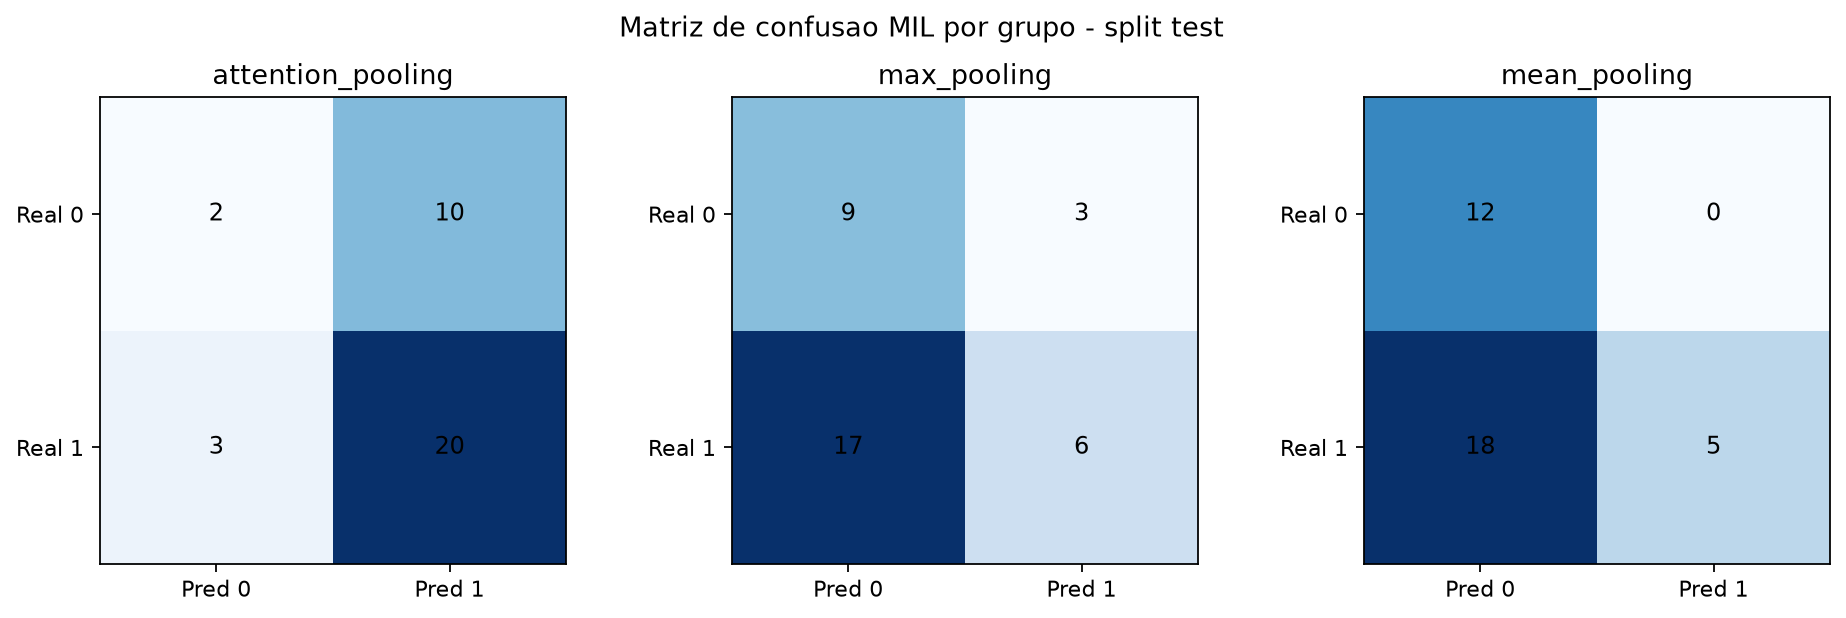

In [7]:
confusion_path = REPORT_FIGURES / "mil_confusion_matrix.png"
if confusion_path.exists():
    display(Image(filename=str(confusion_path), width=900))
else:
    print(f"Figura ainda nao encontrada: {confusion_path}")


## Comparacao com CNN e ROI

Quando as tabelas anteriores existem, esta celula monta uma comparacao por grupo no teste. Ela nao reexecuta a CNN nem os experimentos ROI.


In [8]:
comparison_frames = []

if mil_metrics is not None:
    mil_test = mil_metrics[(mil_metrics["split"] == "test") & (mil_metrics["level"] == "group")].copy()
    mil_test["source"] = mil_test["model"]
    comparison_frames.append(mil_test)

cnn_metrics = read_csv_if_exists(REPORT_TABLES / "baseline_cnn_test_metrics.csv")
if cnn_metrics is not None:
    cnn_group = cnn_metrics.copy()
    if "level" in cnn_group.columns:
        cnn_group = cnn_group[cnn_group["level"] == "group"].copy()
    cnn_group["source"] = "baseline_cnn_full_image"
    comparison_frames.append(cnn_group)

roi_metrics = read_csv_if_exists(REPORT_TABLES / "roi_experiment_comparison.csv")
if roi_metrics is not None:
    roi_group = roi_metrics[(roi_metrics["split"] == "test") & (roi_metrics["level"] == "group")].copy()
    roi_group["source"] = "roi_" + roi_group["approach"].astype(str)
    comparison_frames.append(roi_group)

if comparison_frames:
    comparison = pd.concat(comparison_frames, ignore_index=True, sort=False)
    comparison_columns = [
        "source", "split", "level", "n", "balanced_accuracy", "sensitivity",
        "recall_sensitivity", "specificity", "roc_auc", "average_precision",
        "precision", "recall", "f1",
    ]
    existing_columns = [column for column in comparison_columns if column in comparison.columns]
    display(comparison[existing_columns])
else:
    print("Nenhuma tabela de comparacao encontrada ainda.")


,source,split,level,n,balanced_accuracy,sensitivity,recall_sensitivity,specificity,roc_auc,average_precision,precision,recall,f1
0,mil_attention_pooling,test,group,35,0.518116,0.869565,0.869565,0.166667,0.663043,0.861512,0.666667,0.869565,0.754717
1,mil_max_pooling,test,group,35,0.505435,0.260870,0.260870,0.750000,0.471014,0.678612,0.666667,0.260870,0.375000
2,mil_mean_pooling,test,group,35,0.608696,0.217391,0.217391,1.000000,0.630435,0.801778,1.000000,0.217391,0.357143
3,baseline_cnn_full_image,test,group,35,0.807971,NaN,0.782609,0.833333,0.920290,0.962406,0.900000,NaN,0.837209
4,roi_full_image,test,group,35,0.807971,0.782609,0.782609,0.833333,0.920290,0.962406,0.900000,0.782609,0.837209
5,roi_roi_crop_aproximada,test,group,35,0.849638,0.782609,0.782609,0.916667,0.952899,0.976467,0.947368,0.782609,0.857143
6,roi_roi_mask_heuristica,test,group,35,0.809783,0.869565,0.869565,0.750000,0.952899,0.975383,0.869565,0.869565,0.869565


## Checks

Antes de interpretar resultados, confirme:

- o split continua por `inferred_group_id`;
- nenhuma imagem bruta foi versionada;
- o treino usou apenas `train` e selecionou modelo por `val`;
- o teste foi usado apenas para avaliacao final;
- a configuracao de `image_size`, epocas e `max_slices_per_bag` esta documentada junto com as metricas.


## Takeaways

MIL aproxima a modelagem da unidade metodologica principal do projeto: o grupo inferido. Ele permite testar se uma agregacao aprendida dos slices melhora a predicao por grupo em relacao a media simples das probabilidades por slice.

Mesmo com bom desempenho, o resultado nao prova validade clinica. As limitacoes de JPEG, ausencia de metadados clinicos, ausencia de HU confiavel e ausencia de segmentacao hepatica validada continuam valendo.
